<a href="https://colab.research.google.com/github/Aryan-yadav7/ML_learning/blob/main/crop_yield_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("/japan.csv")

In [ ]:
df['Year'] = pd.to_numeric(df['Year'])
df['Value'] = pd.to_numeric(df['Value'])

In [ ]:
X = df[['Year']]

y = df['Value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[5300.96802043 5629.37181299 6724.05112152 5574.63784756 5848.30767469
 5711.47276113 6505.11525981 5328.33500314 6204.07844996 6833.51905237
 6559.84922524 6094.61051911 5793.57370926]


In [ ]:
errors = y_test - y_pred

squared_errors = errors**2

sum = 0
for i in squared_errors:
  sum = sum + i

n = X_test.shape[0]

mse = sum/n

print("MSE: ", mse)

MSE:  81674.08163546087


In [ ]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 285.786776523094


In [ ]:
errors = y_test - y_pred

absolute_errors = abs(errors)

total = 0
for i in absolute_errors:
  total = total + i

n = X_test.shape[0]

mae = total/n

print("MAE: ", mae)

MAE:  250.9192774738725


In [ ]:
errors = y_test - y_pred

# Sum of squared errors
ss_res = 0
for i in errors:
    ss_res += i ** 2

# Mean of actual test values
mean_y = y_test.mean()

# Total sum of squares
ss_tot = 0
for i in y_test:
    ss_tot += (i - mean_y) ** 2

r2 = 1 - (ss_res / ss_tot)

print("R²:", r2)

R²: 0.8248413564570553


In [ ]:
pred = pd.DataFrame({'Year': [2027, 2028, 2029, 2030]})

ans = model.predict(pred)

for year, prediction in zip(pred['Year'], ans):
    print(year, prediction)


2027 7107.188879500609
2028 7134.555862213849
2029 7161.922844927096
2030 7189.289827640343


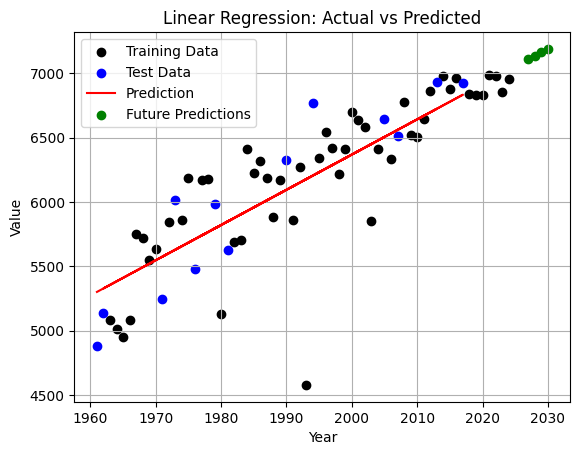

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_train['Year'], y_train, color='black', label='Training Data')
plt.scatter(X_test['Year'], y_test, color='blue', label='Test Data')
plt.plot(X_test['Year'], y_pred, color='red', label='Prediction')

plt.scatter(pred['Year'], ans, color='green', label='Future Predictions')

plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_poly)

print(y_pred)

[5244.38914991 5622.67979546 6720.23109735 5561.20267681 5862.30298095
 5713.71698172 6520.83376209 5276.77759762 6230.24210834 6816.15859152
 6571.62588927 6119.85844924 5803.33997794]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_new = mean_squared_error(y_test, y_pred)
mae_new = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse_new)
print("MAE:", mae_new)
print("R²:", r2)

MSE: 74026.3379536765
MAE: 239.95165341053647
R²: 0.8412427457673682


In [ ]:
future = pd.DataFrame({
    'Year': [2027, 2028, 2029, 2030]
})

future_poly = poly.transform(future)

future_predictions = model.predict(future_poly)

for year, prediction in zip(future['Year'], future_predictions):
    print(f"Year: {year}, Prediction: {prediction}")


Year: 2027, Prediction: 7044.978071022662
Year: 2028, Prediction: 7066.995791721449
Year: 2029, Prediction: 7088.856380192679
Year: 2030, Prediction: 7110.559836436354


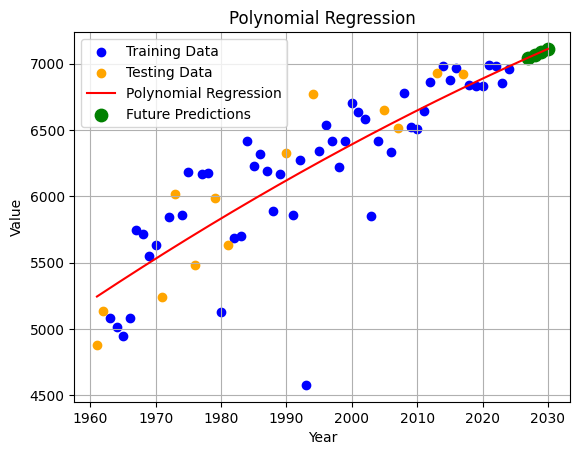

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


y_train_pred = model.predict(X_train_poly)

y_test_pred = model.predict(X_test_poly)

future = pd.DataFrame({
    'Year': [2027, 2028, 2029, 2030]
})

future_poly = poly.transform(future)
future_predictions = model.predict(future_poly)


years = np.linspace(
    df['Year'].min(),
    2030,
    300
)

years_df = pd.DataFrame({'Year': years})
years_poly = poly.transform(years_df)
curve_predictions = model.predict(years_poly)

plt.scatter(
    X_train['Year'],
    y_train,
    color='blue',
    label='Training Data'
)


plt.scatter(
    X_test['Year'],
    y_test,
    color='orange',
    label='Testing Data'
)

plt.plot(
    years,
    curve_predictions,
    color='red',
    label='Polynomial Regression'
)


plt.scatter(
    future['Year'],
    future_predictions,
    color='green',
    s=80,
    label='Future Predictions'
)

plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Polynomial Regression')
plt.legend()
plt.grid(True)

plt.show()